# HYCOM GOFS 3.1 reanalysis — virtual Icechunk smoke test (local)

A small, re-runnable proof that the [HYCOM GOFS 3.1 reanalysis on AWS Open
Data](https://registry.opendata.aws/hycom-gofs-3pt1-reanalysis/) can be published as a
**virtual** [Icechunk](https://icechunk.io) store: Zarr metadata plus byte-range references,
with the 306 TB of arrays left where they are.

It needs **no credentials** and writes only to a temporary local directory. It does not
touch Source Cooperative.

What is unusual about this source, and what this notebook has to prove:

- The files are NetCDF 64-bit offset (NetCDF-3), **uncompressed and unchunked**: each 4-D
  variable is one 1.17 GB byte range. Because nothing is compressed, a depth level is a
  contiguous 29 MB slice of that range, so we reference **one chunk per level** without
  rewriting anything.
- There are 63,341 files of 4.8 GB. Running a parser over each is impractical, so the
  references are **computed from each file's header**, fetched with one small ranged GET.
- The archive has **two header layouts, 40 bytes apart**, mixed within experiments. Offsets
  therefore come from each file's own header — never from a template file.
- 931 of the 64,272 three-hourly steps have no file. The time axis is kept **regular**, and
  those steps are left unreferenced so they read as missing.

The build logic lives in `hycom_virtual.py` so that the production notebook builds the store
the same way.

In [1]:
# Dependencies: pip install -r requirements.txt   (Python >= 3.12 — icechunk 2.x needs it)
import sys, time, shutil, tempfile, urllib.request
from pathlib import Path

import numpy as np, pandas as pd, xarray as xr
import zarr, icechunk, virtualizarr, obstore, netCDF4

import hycom_virtual as hv

print("python      ", sys.version.split()[0])
for m in (icechunk, virtualizarr, xr, zarr, obstore, np, pd, netCDF4):
    print(f"{m.__name__:12s}", m.__version__)

# Zarr's default of 10 concurrent requests badly under-uses object storage. This is a
# reader setting as much as a writer one, and every timing below was taken with it.
zarr.config.set({"async.concurrency": 64});

python       3.12.12
icechunk     2.2.2
virtualizarr 2.7.3
xarray       2026.7.0
zarr         3.4.0
obstore      0.11.1
numpy        2.5.3
pandas       3.0.6
netCDF4      1.7.4


## 1. Discover the source

An anonymous S3 listing — 64 requests for the whole bucket. Valid time comes from the
filename here (run date at 12Z plus the forecast hour); section 3 requires the time stored
*inside* every file we use to agree with it.

In [2]:
store = hv.source_store()
t0 = time.perf_counter()
files = hv.list_files(store)
print(f"{len(files):,} files, {files['size'].sum()/1e12:.1f} TB, listed in {time.perf_counter()-t0:.1f} s")
print(files.index.min(), "→", files.index.max())

axis = hv.time_axis(files)
missing = axis.difference(files.index)
print(f"\nregular 3-hourly axis: {len(axis):,} steps; {len(missing):,} have no file")
print("missing steps by hour of day:", pd.Series(missing.hour).value_counts().sort_index().to_dict())
print("\nfile sizes:", files["size"].value_counts().to_dict())
files.groupby("experiment").apply(lambda g: pd.Series({"first": g.index.min(), "last": g.index.max(), "files": len(g),
                                                       "sizes": g["size"].nunique()}), include_groups=False)

63,341 files, 305.8 TB, listed in 11.4 s
1994-01-01 12:00:00 → 2015-12-31 09:00:00

regular 3-hourly axis: 64,272 steps; 931 have no file
missing steps by hour of day: {0: 46, 3: 47, 6: 49, 9: 67, 12: 593, 15: 37, 18: 46, 21: 46}

file sizes: {4827801984: 35902, 4827801944: 27439}


,first,last,files,sizes
experiment,,,,
530,1994-01-01 12:00:00,1999-04-01 09:00:00,15092,1
531,1999-04-01 12:00:00,2001-01-01 09:00:00,5045,1
532,2001-01-01 12:00:00,2003-07-01 09:00:00,7183,2
533,2003-07-01 12:00:00,2005-07-01 09:00:00,5777,2
534,2005-07-01 12:00:00,2007-07-01 09:00:00,5767,1
535,2007-07-01 12:00:00,2009-07-01 09:00:00,5765,2
536,2009-07-01 12:00:00,2011-07-01 09:00:00,5783,2
537,2011-07-01 12:00:00,2013-07-01 09:00:00,5770,2
538,2013-07-01 12:00:00,2014-12-31 09:00:00,4298,1


## 2. Prove byte-range access on the reference URL

The references will be HTTPS URLs, so this is the request a reader's Icechunk will make.
It must return **206** and the NetCDF 64-bit-offset magic number `CDF\x02`.

In [3]:
url = hv.URL_PREFIX + files["key"].iloc[0]
req = urllib.request.Request(url, headers={"Range": "bytes=0-3"})
with urllib.request.urlopen(req, timeout=60) as r:
    status, magic, crange = r.status, r.read(), r.headers["Content-Range"]
print(url); print(status, magic, crange)
assert status == 206 and magic == b"CDF\x02"

https://hycom-gofs-3pt1-reanalysis.s3.us-west-2.amazonaws.com/1994/hycom_GLBv0.08_530_1994010112_t000.nc
206 b'CDF\x02' bytes 0-3/4827801984


## 3. Choose the test files and check every one of them

Four short windows, one on each side of every transition we know about:

| window | why |
|---|---|
| `first_1994` | the first files in the archive |
| `boundary_1999` | the change from experiment 53.0 to 53.1 |
| `gap_2004` | **both header layouts and a missing step**, inside one experiment |
| `last_2015` | the last files in the archive |

`scan_headers` makes one 67 kB ranged GET per file. `check_scan` then refuses to go on
unless every file has one record, the same schema and byte-identical coordinates, a size
that matches what its header implies, and an in-file `time` and `tau` equal to the ones in
its filename.

In [4]:
WINDOWS = {
    "first_1994":    ("1994-01-01 12:00", "1994-01-01 21:00"),
    "boundary_1999": ("1999-04-01 03:00", "1999-04-01 18:00"),
    "gap_2004":      ("2004-12-27 12:00", "2004-12-29 09:00"),
    "last_2015":     ("2015-12-31 00:00", "2015-12-31 09:00"),
}
test_files = pd.concat([files.loc[a:b] for a, b in WINDOWS.values()])

t0 = time.perf_counter()
scan = hv.scan_headers(store, test_files)
print(f"{len(scan)} headers in {time.perf_counter()-t0:.1f} s")
hv.check_scan(test_files, scan)
print("check_scan passed: one record, one schema, identical coordinates, sizes and times agree")

summary = test_files[["experiment", "tau", "size"]].join(scan[["header_len", "begin_water_temp"]])
summary["window"] = [next(k for k, (a, b) in WINDOWS.items() if pd.Timestamp(a) <= t <= pd.Timestamp(b)) for t in summary.index]
print("\nheader layouts in the test set:", scan["header_len"].value_counts().to_dict())
summary.loc["2004-12-28 03:00":"2004-12-28 18:00"]

29 headers in 0.2 s
check_scan passed: one record, one schema, identical coordinates, sizes and times agree

header layouts in the test set: {4640: 21, 4600: 8}


,experiment,tau,size,header_len,begin_water_temp,window
time,,,,,,
2004-12-28 03:00:00,533,15,4827801944,4600,2399304944,gap_2004
2004-12-28 06:00:00,533,18,4827801944,4600,2399304944,gap_2004
2004-12-28 09:00:00,533,21,4827801944,4600,2399304944,gap_2004
2004-12-28 15:00:00,533,3,4827801984,4640,2399304984,gap_2004
2004-12-28 18:00:00,533,6,4827801984,4640,2399304984,gap_2004


The rows above show the point of the exercise: consecutive files in the same experiment
with `begin_water_temp` 40 bytes apart, and no row at all for 2004-12-28 12:00.

### What differs between the two layouts

In [5]:
short_key = test_files.loc[scan["header_len"] == scan["header_len"].min(), "key"].iloc[0]
long_key  = test_files.loc[scan["header_len"] == scan["header_len"].max(), "key"].iloc[0]
(h_short, _), (h_long, buf) = hv.read_header(store, short_key), hv.read_header(store, long_key)
print("short:", short_key, h_short["header_len"]); print("long: ", long_key, h_long["header_len"])
assert h_short["attrs"] == h_long["attrs"]
for name, v in h_long["variables"].items():
    for k in v["attrs"]:
        a, b = h_short["variables"][name]["attrs"].get(k), v["attrs"][k]
        if np.any(a != b):
            print(f"  {name}:{k}  {a!r}  |  {b!r}")

short: 2004/hycom_GLBv0.08_533_2004122712_t000.nc 4600
long:  1994/hycom_GLBv0.08_530_1994010112_t000.nc 4640
  tau:time_origin  '2004-12-27 12:00:00'  |  '1994-01-01 12:00:00'
  water_u_bottom:standard_name  'eastward_sea_water_velocity'  |  'eastward_sea_water_velocity_at_bottom'
  water_v_bottom:standard_name  'northward_sea_water_velocity'  |  'northward_sea_water_velocity_at_bottom'
  water_temp_bottom:standard_name  'sea_water_temperature'  |  'sea_water_temperature_at_bottom'
  salinity_bottom:standard_name  'sea_water_salinity'  |  'sea_water_salinity_at_bottom'


### One representative file

In [6]:
header = h_long
print("format: CDF-%d   records: %d   header bytes: %d" % (header["version"], header["numrecs"], header["header_len"]))
print("dims:", header["dims"])
rows = [dict(variable=n, dims=" ".join(v["dims"]), shape=tuple(v["shape"]), dtype=v["dtype"], bytes=v["vsize"], begin=v["begin"],
             scale_factor=v["attrs"].get("scale_factor"), add_offset=v["attrs"].get("add_offset"),
             fill=v["attrs"].get("_FillValue"), standard_name=v["attrs"].get("standard_name"), units=v["attrs"].get("units"))
        for n, v in header["variables"].items()]
pd.DataFrame(rows).set_index("variable")

format: CDF-2   records: 1   header bytes: 4640
dims: [('lat', 3251), ('lon', 4500), ('depth', 40), ('time', 0)]


,dims,shape,dtype,bytes,begin,scale_factor,add_offset,fill,standard_name,units
variable,,,,,,,,,,
time,time,"(1,)",>f8,8,66968,NaN,NaN,NaN,NaN,hours since 2000-01-01 00:00:00
tau,time,"(1,)",>f8,8,66976,NaN,NaN,NaN,NaN,hours since analysis
depth,depth,"(40,)",>f8,320,4640,NaN,NaN,NaN,depth,m
lat,lat,"(3251,)",>f8,26008,4960,NaN,NaN,NaN,latitude,degrees_north
lon,lon,"(4500,)",>f8,36000,30968,NaN,NaN,NaN,longitude,degrees_east
water_u,time depth lat lon,"(1, 40, 3251, 4500)",>i2,1170360000,66984,0.001,0.0,-30000.0,eastward_sea_water_velocity,m/s
water_u_bottom,time lat lon,"(1, 3251, 4500)",>i2,29259000,1170426984,0.001,0.0,-30000.0,eastward_sea_water_velocity_at_bottom,m/s
water_v,time depth lat lon,"(1, 40, 3251, 4500)",>i2,1170360000,1199685984,0.001,0.0,-30000.0,northward_sea_water_velocity,m/s
water_v_bottom,time lat lon,"(1, 3251, 4500)",>i2,29259000,2370045984,0.001,0.0,-30000.0,northward_sea_water_velocity_at_bottom,m/s


## 4. Metadata repairs

Metadata is the one thing a virtual store can fix, so it is made CF-compliant. **No array
value changes.** Standard names were checked against CF standard-name table v94 and units
against UDUNITS. The source's `psu` does not parse as a unit at all, and `hours since
analysis` does not parse as a time unit.

In [7]:
changes = []
for name in hv.SCIENCE_VARS:
    src = header["variables"][name]["attrs"]
    new, _enc = hv.science_attrs(header, name)
    for k in new:
        if hv._jsonable(src.get(k)) != new[k]:
            changes.append(dict(variable=name, attribute=k, source=src.get(k), store=new[k]))
t = header["variables"]
changes += [dict(variable="tau", attribute="units", source=t["tau"]["attrs"]["units"], store="hours"),
            dict(variable="tau", attribute="standard_name", source=None, store="forecast_period"),
            dict(variable="tau", attribute="time_origin", source="(the run date, differs per file)", store="(dropped)"),
            dict(variable="time", attribute="calendar", source=t["time"]["attrs"]["calendar"], store="standard"),
            dict(variable="(global)", attribute="Conventions", source=header["attrs"]["Conventions"], store=hv.global_attrs(header)["Conventions"])]
pd.DataFrame(changes).set_index(["variable", "attribute"])

source  \
variable          attribute                                                
water_temp        units_metadata                                     NaN   
salinity          long_name                                     Salinity   
                  units                                              psu   
                  source_units                                       NaN   
water_u_bottom    standard_name    eastward_sea_water_velocity_at_bottom   
water_v_bottom    standard_name   northward_sea_water_velocity_at_bottom   
water_temp_bottom standard_name          sea_water_temperature_at_bottom   
                  units_metadata                                     NaN   
salinity_bottom   long_name                                     Salinity   
                  standard_name             sea_water_salinity_at_bottom   
                  units                                              psu   
                  source_units                                       NaN   
surf_el           standard_name                    sea_surface_elevation   
tau               units                             hours since analysis   
                  standard_name                                      NaN   
                  time_origin           (the run date, differs per file)   
time              calendar                                     gregorian   
(global)          Conventions                    CF-1.6 NAVO_netcdf_v1.1   

                                                                      store  
variable          attribute                                                  
water_temp        units_metadata                      temperature: on_scale  
salinity          long_name                              Sea Water Salinity  
                  units                                                1e-3  
                  source_units                                          psu  
water_u_bottom    standard_name    eastward_sea_water_velocity_at_sea_floor  
water_v_bottom    standard_name   northward_sea_water_velocity_at_sea_floor  
water_temp_bottom standard_name          sea_water_temperature_at_sea_floor  
                  units_metadata                      temperature: on_scale  
salinity_bottom   long_name                 Sea Water Salinity at Sea Floor  
                  standard_name             sea_water_salinity_at_sea_floor  
                  units                                                1e-3  
                  source_units                                          psu  
surf_el           standard_name              sea_surface_height_above_geoid  
tau               units                                               hours  
                  standard_name                             forecast_period  
                  time_origin                                     (dropped)  
time              calendar                                         standard  
(global)          Conventions                                       CF-1.11

## 5. Build a temporary local repository

The repository config carries the **virtual chunk container** — the URL prefix readers are
allowed to follow, which must end in `/` — and splits manifests along `time`.
`repo.save_config()` persists it so that a later reader can discover the container.

`gap_2004` is written the way production will be: a **skeleton** first (the full-length
coordinates, including `tau` and `experiment`, and science arrays holding no references), then the
references in **region batches**, one commit each with a fresh session. The other three
windows are written in one shot, which exercises the simpler path.

In [8]:
workdir = Path(tempfile.mkdtemp(prefix="hycom-smoke-"))
repo_path = workdir / "repo"
repo = icechunk.Repository.create(icechunk.local_filesystem_storage(str(repo_path)), hv.repository_config(time_chunks_per_manifest=8))
repo.save_config()
print(repo_path)

def window(name):
    a, b = WINDOWS[name]
    f = test_files.loc[a:b]
    return f, scan.loc[f.index], pd.date_range(a, b, freq=hv.FREQ)

# --- gap_2004: skeleton, then two region batches
f, s, times = window("gap_2004")
skeleton = xr.merge([hv.loaded_variables(f, header, buf, times), hv.virtual_variables(f.iloc[:0], s.iloc[:0], header, times)])
skeleton.attrs = hv.global_attrs(header)
session = repo.writable_session("main")
skeleton.vz.to_icechunk(session.store, group="gap_2004")
print("skeleton  ", session.commit("gap_2004: skeleton"))
for a, b in [(0, 8), (8, 16)]:
    batch = hv.virtual_variables(f, s, header, times[a:b])
    session = repo.writable_session("main")               # a committed session is read-only
    batch.vz.to_icechunk(session.store, group="gap_2004", region={"time": slice(a, b)})
    print(f"refs {a:2d}:{b:2d}", session.commit(f"gap_2004: references for {times[a]} .. {times[b-1]}"))

# --- the other windows: one write each
for name in ("first_1994", "boundary_1999", "last_2015"):
    f, s, times = window(name)
    vds = xr.merge([hv.loaded_variables(f, header, buf, times), hv.virtual_variables(f, s, header, times)])
    vds.attrs = hv.global_attrs(header)
    session = repo.writable_session("main")
    vds.vz.to_icechunk(session.store, group=name)
    print(f"{name:14s}", session.commit(f"{name}: {len(f)} files"))

size = sum(p.stat().st_size for p in repo_path.rglob("*") if p.is_file())
print(f"\nrepository on disk: {size/1e3:.0f} kB in {sum(1 for p in repo_path.rglob('*') if p.is_file())} files, "
      f"referencing {test_files['size'].sum()/1e9:.0f} GB")

/tmp/hycom-smoke-49arrc2l/repo


  2026-09-18T22:43:21.630388Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-09-18T22:43:21.632108Z  WARN icechunk_storage::readback: conditional PUT is enabled but `unsafe_use_metadata` is disabled — lost-response recovery for conditional writes requires user metadata to stamp write-ids; without it, transient PUT failures may surface as spurious conflicts even when the write actually landed. See icechunk_storage::Settings::unsafe_use_metadata.
    at icechunk-storage/src/readback.rs:31



skeleton   XZ0WCCWY8ZH1Y5N2TXG0
refs  0: 8 8C0NH5KX928AAA5BAVHG
refs  8:16 ZZ3ZSMASB57HA1KD07SG


first_1994     R6DJW92GGNXEN2V16Q0G
boundary_1999  4452N18ZDEXBG8DZTAJG
last_2015      MGQVZNDCYHQTDJ3BTWD0

repository on disk: 186 kB in 99 files, referencing 140 GB


## 6. Reopen as a reader would

A **new** `Repository.open` — not the writer's object — with the virtual container read
back from the saved config and authorized explicitly. Anonymous HTTPS needs the
`HttpAccess` sentinel; leaving it out is the classic "metadata opens, data reads fail".

In [9]:
del repo, session
probe = icechunk.Repository.open(icechunk.local_filesystem_storage(str(repo_path)))
containers = list(probe.config.virtual_chunk_containers or [])
print("containers in the saved config:", containers)
assert containers == [hv.URL_PREFIX]

reader = icechunk.Repository.open(icechunk.local_filesystem_storage(str(repo_path)),
                                  authorize_virtual_chunk_access={p: icechunk.credentials.HttpAccess for p in containers})
ro = reader.readonly_session("main").store
t0 = time.perf_counter()
ds = {name: xr.open_zarr(ro, group=name, consolidated=False, chunks={}) for name in WINDOWS}
print(f"opened {len(ds)} groups in {time.perf_counter()-t0:.2f} s")
ds["gap_2004"]

containers in the saved config: ['https://hycom-gofs-3pt1-reanalysis.s3.us-west-2.amazonaws.com/']


opened 4 groups in 0.12 s


  2026-09-18T22:43:22.284222Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-09-18T22:43:22.285407Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330



<xarray.Dataset> Size: 309GB
Dimensions:            (time: 16, lat: 3251, lon: 4500, depth: 40)
Coordinates:
  * time               (time) datetime64[ns] 128B 2004-12-27T12:00:00 ... 200...
    experiment         (time) int16 32B dask.array<chunksize=(16,), meta=np.ndarray>
    tau                (time) float64 128B dask.array<chunksize=(16,), meta=np.ndarray>
  * lat                (lat) float64 26kB -80.0 -79.96 -79.92 ... 89.96 90.0
  * lon                (lon) float64 36kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * depth              (depth) float64 320B 0.0 2.0 4.0 ... 3e+03 4e+03 5e+03
Data variables:
    salinity_bottom    (time, lat, lon) float64 2GB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    surf_el            (time, lat, lon) float64 2GB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    water_temp         (time, depth, lat, lon) float64 75GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_u_bottom     (time, lat, lon) float64 2GB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    water_v_bottom     (time, lat, lon) float64 2GB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    salinity           (time, depth, lat, lon) float64 75GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_temp_bottom  (time, lat, lon) float64 2GB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    water_u            (time, depth, lat, lon) float64 75GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_v            (time, depth, lat, lon) float64 75GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
Attributes: (12/15)
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    ...                        ...
    title:                     HYCOM GOFS 3.1 Global Ocean Reanalysis, GLBv0....
    experiment_id:             GLBv0.08 expt_53.X
    source_Conventions:        CF-1.6 NAVO_netcdf_v1.1
    references:                https://www.hycom.org/dataserver/gofs-3pt1/rea...
    source_data:               s3://hycom-gofs-3pt1-reanalysis (us-west-2), N...
    comment:                   Virtual Icechunk store: Zarr metadata and byte...

## 7. Assert the structure

In [10]:
for name, d in ds.items():
    a, b = WINDOWS[name]
    expected = pd.date_range(a, b, freq=hv.FREQ)
    assert d.time.to_index().equals(expected), name                     # regular axis, in order
    assert dict(d.sizes) == {"time": len(expected), "depth": 40, "lat": 3251, "lon": 4500}
    assert set(d.data_vars) == set(hv.SCIENCE_VARS) and {"tau", "experiment"} <= set(d.water_temp.coords)
    for v in hv.VARS_4D:
        assert d[v].encoding["chunks"] == (1, 1, 3251, 4500) and d[v].encoding["dtype"] == np.int16
        assert not d[v].encoding["compressors"] and d[v].encoding["serializer"].endian == "big"
    for v in hv.VARS_2D:
        assert d[v].encoding["chunks"] == (1, 3251, 4500)
    assert d.time.encoding["chunks"] == (len(expected),)                 # one chunk, not one per step
    assert d.experiment.dtype == np.int16
    assert d.salinity.attrs["units"] == "1e-3" and d.salinity.attrs["source_units"] == "psu"
    assert d.water_temp_bottom.attrs["standard_name"] == "sea_water_temperature_at_sea_floor"
    assert d.tau.attrs["standard_name"] == "forecast_period" and d.tau.attrs["units"] == "hours"
    assert d.attrs["experiment_id"] == hv.EXPERIMENT_ID and hv.EXPERIMENT_ID.split()[1] in d.attrs["title"]
    have = test_files.loc[a:b]
    assert np.array_equal(d.tau.notnull().values, expected.isin(have.index))
    assert np.array_equal(d.experiment.values, have["experiment"].reindex(expected).fillna(0).astype("i2").values)
print("structure OK for", list(ds))

g = ds["gap_2004"]
print("\ngap_2004  tau:       ", g.tau.values)
print("gap_2004  experiment:", g.experiment.values)
print("boundary  experiment:", ds["boundary_1999"].experiment.values)
# `.values` matters: with chunks={} `tau` is a dask array, and xarray refuses a lazy boolean indexer
present = g.isel(time=g.tau.notnull().values)
print("\nthe present-only view is one line:", present.sizes["time"], "of", g.sizes["time"], "steps")

structure OK for ['first_1994', 'boundary_1999', 'gap_2004', 'last_2015']

gap_2004  tau:        [ 0.  3.  6.  9. 12. 15. 18. 21. nan  3.  6.  9. 12. 15. 18. 21.]
gap_2004  experiment: [533 533 533 533 533 533 533 533   0 533 533 533 533 533 533 533]
boundary  experiment: [530 530 530 531 531 531]



the present-only view is one line: 15 of 16 steps


## 8. Compare against an independent reader

The store holds no data, so "is it right" means "does a read through a reference return the
bytes in the file". The check uses **netCDF4-C's own byte-range reader** on the source URL
— nothing of ours — and compares **raw `int16`**, so equality is exact. For every file
listed: all nine variables, and for the 4-D ones the top, a middle and the bottom level.

A 40-byte offset error would shift every row by 20 cells, so this is the test that the
two-layout handling is right.

In [11]:
raw = {name: xr.open_zarr(ro, group=name, consolidated=False, chunks={}, mask_and_scale=False) for name in WINDOWS}
BOX = dict(lat=slice(1500, 1512), lon=slice(2000, 2012))     # position printed below
LEVELS = [0, 17, 39]

def check_file(group, t):
    key = test_files.loc[t, "key"]
    nc = netCDF4.Dataset(hv.URL_PREFIX + key + "#mode=bytes")
    nc.set_auto_maskandscale(False)
    n = 0
    for v in hv.SCIENCE_VARS:
        sel = raw[group][v].sel(time=[t]).isel(**BOX)
        if v in hv.VARS_4D:
            mine = sel.isel(depth=LEVELS).values[0]
            truth = np.stack([nc[v][0, z, BOX["lat"], BOX["lon"]] for z in LEVELS])
        else:
            mine, truth = sel.values[0], nc[v][0, BOX["lat"], BOX["lon"]]
        assert mine.dtype == np.int16 and np.array_equal(mine, truth), (key, v)
        n += mine.size
    nc.close()
    return key, n

to_check = [("first_1994", "1994-01-01 12:00"), ("boundary_1999", "1999-04-01 09:00"), ("boundary_1999", "1999-04-01 12:00"),
            ("gap_2004", "2004-12-28 09:00"), ("gap_2004", "2004-12-28 15:00"), ("last_2015", "2015-12-31 09:00")]
print("box:", float(ds["gap_2004"].lat[1500]), "N,", float(ds["gap_2004"].lon[2000]), "E")
t0 = time.perf_counter()
for group, t in to_check:
    key, n = check_file(group, pd.Timestamp(t))
    print(f"identical  {n:5d} int16 values  header {scan.loc[pd.Timestamp(t), 'header_len']}  {key}")
print(f"{time.perf_counter()-t0:.0f} s")

box:

 0.0 N, -20.0 E


identical   2448 int16 values  header 4640  1994/hycom_GLBv0.08_530_1994010112_t000.nc


identical   2448 int16 values  header 4640  1999/hycom_GLBv0.08_530_1999033112_t021.nc


identical   2448 int16 values  header 4640  1999/hycom_GLBv0.08_531_1999040112_t000.nc


identical   2448 int16 values  header 4600  2004/hycom_GLBv0.08_533_2004122712_t021.nc


identical   2448 int16 values  header 4640  2004/hycom_GLBv0.08_533_2004122812_t003.nc


identical   2448 int16 values  header 4640  2015/hycom_GLBv0.08_539_2015123012_t021.nc
56 s


Decoded values, fill handling, and the missing step:

In [12]:
g = ds["gap_2004"]
t = pd.Timestamp("2004-12-28 09:00")
nc = netCDF4.Dataset(hv.URL_PREFIX + test_files.loc[t, "key"] + "#mode=bytes")    # netCDF4 masks and scales by default
truth = np.ma.filled(nc["water_temp"][0, 39, 1200:1260, 2000:2060].astype("f8"), np.nan)
nc.close()
mine = g.water_temp.sel(time=[t]).isel(depth=[39], lat=slice(1200, 1260), lon=slice(2000, 2060)).values[0, 0]
print("deep level: %d of %d cells are fill in both readers" % (np.isnan(truth).sum(), truth.size))
assert np.array_equal(np.isnan(mine), np.isnan(truth)) and np.allclose(mine, truth, equal_nan=True, atol=1e-5)
print("decoded values agree to 1e-5 (netCDF4 computes in float32, xarray here in float64):", mine.dtype)

t0 = time.perf_counter()
hole = g.water_temp.sel(time=["2004-12-28 12:00"]).isel(depth=[0]).load()
print(f"\nmissing step: all NaN = {bool(hole.isnull().all())}, read in {time.perf_counter()-t0:.2f} s (no reference, so nothing is fetched)")
assert hole.isnull().all()

deep level: 3519 of 3600 cells are fill in both readers
decoded values agree to 1e-5 (netCDF4 computes in float32, xarray here in float64): float64



missing step: all NaN = True, read in 0.28 s (no reference, so nothing is fetched)


## 9. Read timings

Observations, not benchmarks: this hub is in **us-west-2, the same region as the source
bucket**, `async.concurrency = 64`, local repository. Data reads go to the source bucket, so
a reader elsewhere will see the same shapes and slower numbers.

Every read of a level fetches the whole 29 MB level, however small the selection. That is
why the point time series is the expensive one, and no setting can change it.

In [13]:
def timed(label, fn):
    t0 = time.perf_counter(); out = fn(); dt = time.perf_counter() - t0
    print(f"{label:58s} {dt:6.2f} s   result {out.nbytes/1e6:8.2f} MB")
    return out

g = ds["gap_2004"]; t = "2004-12-28 09:00"
sst  = timed("one level, global map (1 chunk, 29 MB)",          lambda: g.water_temp.sel(time=[t]).isel(depth=[0]).load())
_    = timed("surface elevation, global map (1 chunk)",         lambda: g.surf_el.sel(time=[t]).load())
_    = timed("full-depth profile at a point (40 chunks, 1.2 GB)", lambda: g.water_temp.sel(time=[t]).sel(lat=[30], lon=[-150], method="nearest").load())
_    = timed("section along 150 W, all depths (40 chunks)",     lambda: g.water_temp.sel(time=[t]).sel(lon=[-150], method="nearest").load())
_    = timed("16-step surface time series at a point (15 chunks)", lambda: g.water_temp.isel(depth=[0]).sel(lat=[30], lon=[-150], method="nearest").load())
_    = timed("16-step mean surface elevation, 20x20 deg box",   lambda: g.surf_el.sel(lat=slice(20, 40), lon=slice(-160, -140)).mean("time").load())
per_step = 29.259e6
print(f"\na single-level point series over the whole record would fetch {len(files)*per_step/1e12:.2f} TB")

one level, global map (1 chunk, 29 MB)                       0.42 s   result   117.04 MB


surface elevation, global map (1 chunk)                      0.37 s   result   117.04 MB


full-depth profile at a point (40 chunks, 1.2 GB)            5.59 s   result     0.00 MB


section along 150 W, all depths (40 chunks)                  4.78 s   result     1.04 MB


16-step surface time series at a point (15 chunks)           2.78 s   result     0.00 MB


16-step mean surface elevation, 20x20 deg box                1.46 s   result     0.50 MB

a single-level point series over the whole record would fetch 1.85 TB


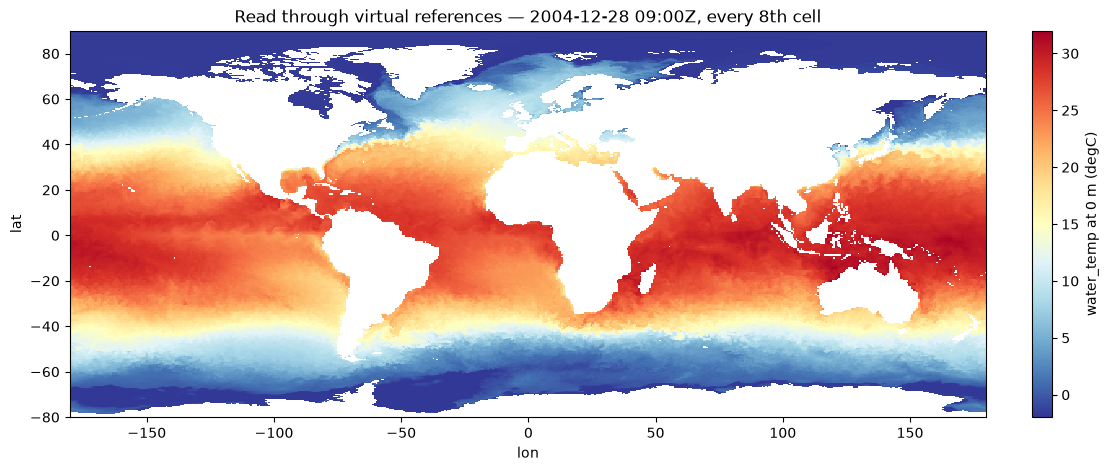

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
m = ax.pcolormesh(sst.lon[::8], sst.lat[::8], sst.values[0, 0, ::8, ::8], cmap="RdYlBu_r", vmin=-2, vmax=32, shading="auto")
fig.colorbar(m, ax=ax, label="water_temp at 0 m (degC)")
ax.set(title=f"Read through virtual references — {t}Z, every 8th cell", xlabel="lon", ylabel="lat")
plt.show()

## 10. CF check

The IOOS compliance checker reads NetCDF, not Zarr, so a tiny corner of the store is written
out with its metadata intact and checked against the convention the store declares.

In [15]:
cf_nc = workdir / "cf-check.nc"
sub = raw["gap_2004"].isel(time=slice(7, 10), depth=slice(0, 2), lat=slice(1500, 1503), lon=slice(2000, 2003)).load()
for v in sub.variables:                                  # Zarr-only encoding keys mean nothing to NetCDF
    sub[v].encoding = {k: x for k, x in sub[v].encoding.items() if k in ("dtype", "units", "calendar", "_FillValue")}
    if v in sub.dims:
        sub[v].encoding["_FillValue"] = None             # as in the store; xarray would otherwise add one on export
# Zarr attributes are JSON, so they carry no dtype; NetCDF's do, and CF wants flag_values typed like the variable.
sub["experiment"].attrs["flag_values"] = np.asarray(sub["experiment"].attrs["flag_values"], sub["experiment"].dtype)
sub.to_netcdf(cf_nc)
suite = "cf:" + ds["gap_2004"].attrs["Conventions"].split("-")[1]
from compliance_checker.runner import ComplianceChecker, CheckSuite
CheckSuite.load_all_available_checkers()
passed, errors = ComplianceChecker.run_checker(str(cf_nc), [suite], verbose=1, criteria="normal")
print("\n%s passed: %s   checker errors: %s" % (suite, passed, errors))



--------------------------------------------------------------------------------
                         IOOS Compliance Checker Report                         
                                 Version 6.1.0                                  
                     Report generated 2026-09-18T22:44:39Z                      
                                    cf:1.11                                     
http://cfconventions.org/Data/cf-conventions/cf-conventions-1.11/cf-conventions.html
--------------------------------------------------------------------------------
All tests passed!

cf:1.11 passed: True   checker errors: False


## 11. Still unknown after this test

- **The full header scan** (63,341 ranged GETs, about 4 GB) has not been run; only the 200-file
  sample in the plan and the files above. `check_scan` is what will catch a third layout or a
  bad file, and the production notebook must run it over everything before writing.
- **Manifest size and open time at full scale**: about 10.5 million references. The
  `time`-split of 2920 steps per manifest is a starting point to measure, not a result.
- **Writing to Source Cooperative** — a separate notebook, against the scratch prefix
  `ocean-icechunks/test-repo/hycom`, never the published one.
- **Reads from outside us-west-2**, and whether S3 throttles a wide parallel read of one
  4.8 GB object.
- **Browser access**: the source bucket sends no `Access-Control-Allow-Origin` on a ranged GET
  (checked 2026-09-18), so a browser viewer will draw the axes and no data until the bucket
  owner adds a CORS policy. Nothing in this notebook says anything about browsers.
- hycom.org publishes its own note on missing days; our list of 931 missing steps has not yet
  been reconciled with it.

In [16]:
shutil.rmtree(workdir)          # only the temporary directory this notebook created
print("removed", workdir)

removed /tmp/hycom-smoke-49arrc2l
